In [ ]:
class HashTable:
    def __init__(self):
        self.table = [None]* 1000
        self.collision_cnt = 0

    def _hash(self, key):
        return hash(key)

    def _index(self, key):
        h = self._hash(key)
        index = h % 1000
        return index

    def add(self, key, value):
        index = self._index(key)
        if self.table[index] is None:
            self.table[index] = (key, value)
        else:
            self.collision_cnt += 1

    def get(self, key, default_value=None):
        index = self._index(key)
        elem = self.table[index]
        if elem:
            return elem[1]
        return default_value

In [78]:
hash('1')

44564096650867108

In [79]:
abs(hash('cat'))

1930588028033140689

In [80]:
hash_table = HashTable()
hash_table.add('cat', 'кошка')
hash_table.add('dog', 'собака')
hash_table.add('monkey', 'обезьяна')

-1930588028033140689 0
240217319380027196 0
7595224848780021273 0


/var/folders/5d/rj2vhd7s3lgf7m08mvzp24xr0000gn/T/ipykernel_64181/1470921594.py:13: RuntimeWarning: overflow encountered in exp
  index = int(1/(1+np.exp(-0.00001 * h%1000000)) * 999)


In [81]:
hash_table.get('monkey')

7595224848780021273 0


/var/folders/5d/rj2vhd7s3lgf7m08mvzp24xr0000gn/T/ipykernel_64181/1470921594.py:13: RuntimeWarning: overflow encountered in exp
  index = int(1/(1+np.exp(-0.00001 * h%1000000)) * 999)


'кошка'

In [82]:
hash_table.get('dog')

240217319380027196 0


/var/folders/5d/rj2vhd7s3lgf7m08mvzp24xr0000gn/T/ipykernel_64181/1470921594.py:13: RuntimeWarning: overflow encountered in exp
  index = int(1/(1+np.exp(-0.00001 * h%1000000)) * 999)


'кошка'

In [83]:
hash_table.get('kajsfnlasf', 'no such element')

-5969027198112733359 0


/var/folders/5d/rj2vhd7s3lgf7m08mvzp24xr0000gn/T/ipykernel_64181/1470921594.py:13: RuntimeWarning: overflow encountered in exp
  index = int(1/(1+np.exp(-0.00001 * h%1000000)) * 999)


'кошка'

In [84]:
hash_table = HashTable()
for i in range(1000):
    hash_table.add(str(i), i)

cnt = 0
for i in range(1000):
    elem = hash_table.get(str(i))
    if elem == i:
        cnt += 1

3828974818870257543 0
44564096650867108 0
2880832459727797722 0
721096095454839894 0
2067167501735095162 0
1867656685433031517 0
6120767426097040685 0
8749977642965834737 0
-5094171571584373791 0
-7420989475595925297 0
3355065291622490507 0
2618407926296978306 0
5996532291333605390 0
5964236626576888825 0
-2577940898707355800 0
7618091377715368541 0
6461736020219754033 0
-5096185004242431201 0
-3434472839331314818 0
-8195478264718847390 0
873438134001307839 0
-703565279688293129 0
-5455672892760358686 0
3158755647191230528 0
-939904559438527796 0
-7042328080800494025 0
-3622156592067539561 0
2504843336092240776 0
5663466549860190199 0
-3106384959609616790 0
-7385138576808997084 0
-2282796640771995113 0
-7491827891670547894 0
-3323940591313031424 0
5556902284998015294 0
3996300676614862058 0
-5653963693139805120 0
6656133375800042448 0
-4211944715700291819 0
12925075468040715 0
5184398414820839387 0
-1786218818405251908 0
1520525252098219849 0
-6989519020039706035 0
-1727521281909306746

/var/folders/5d/rj2vhd7s3lgf7m08mvzp24xr0000gn/T/ipykernel_64181/1470921594.py:13: RuntimeWarning: overflow encountered in exp
  index = int(1/(1+np.exp(-0.00001 * h%1000000)) * 999)


In [71]:
cnt

2

In [72]:
hash_table.collision_cnt

998

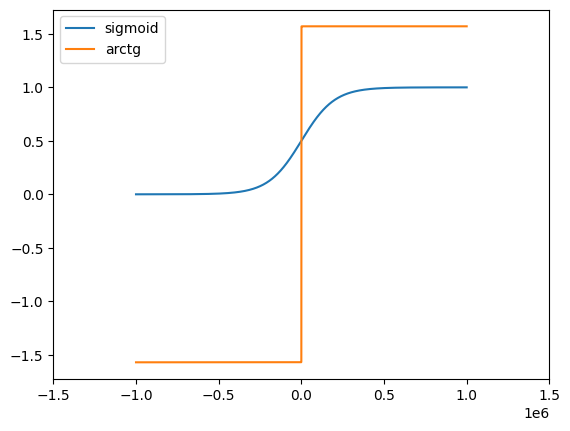

In [55]:
import numpy as np
from matplotlib import pyplot as plt

x = np.arange(-1000000, 1000000, 1)
sigmoid = 1/(1+np.exp(-0.00001*x))
arctg = np.arctan(x)

plt.plot(x, sigmoid, label='sigmoid')
plt.plot(x, arctg, label='arctg')
plt.xlim([-1500000, 1500000])
plt.legend()

In [58]:
sigmoid_int = (sigmoid*100000).astype('int64')
s_set = set(sigmoid_int)
len(s_set)

99992

In [117]:
class HashTableChains:
    def __init__(self):
        self.table = [[] for _ in range(1000)]
        self.collision_cnt = 0

    def _hash(self, key):
        return hash(key)

    def _index(self, key):
        h = self._hash(key)
        index = h % 1000
        return index

    def add(self, key, value):
        index = self._index(key)
        if len(self.table[index]) != 0:
            self.collision_cnt += 1
        self.table[index].append((key, value))

    def get(self, key, default_value=None):
        index = self._index(key)
        elems = self.table[index]
        for elem in elems:
            if elem[0] == key:
                return elem[1]
        return default_value

    def get_lens(self):
        lens = []
        for i in range(len(self.table)):
            lens.append(len(self.table[i]))
        return lens

    def get_free_cells(self):
        cnt = 0
        for i in range(len(self.table)):
            if len(self.table[i]) == 0:
                cnt += 1
        return cnt

In [118]:
hash_table = HashTableChains()
for i in range(1000):
    hash_table.add(str(i), i)

cnt = 0
for i in range(1000):
    elem = hash_table.get(str(i))
    if elem == i:
        cnt += 1

In [119]:
cnt

1000

In [120]:
hash_table.collision_cnt

362

In [121]:
lens = hash_table.get_lens()

In [122]:
np.max(lens)

6

In [123]:
np.mean(lens)

1.0

In [125]:
cnts = []
free = []
collisions = []
ls = [10, 100, 1000, 10000, 100000, 1000000]
for l in ls:
    hash_table = HashTableChains()
    for i in range(l):
        hash_table.add(str(i), i)
    collisions.append(hash_table.collision_cnt)
    free.append(hash_table.get_free_cells())
    cnt = 0
    for i in range(l):
        elem = hash_table.get(str(i))
        if elem == i:
            cnt += 1
    

(0.0, 10000.0)

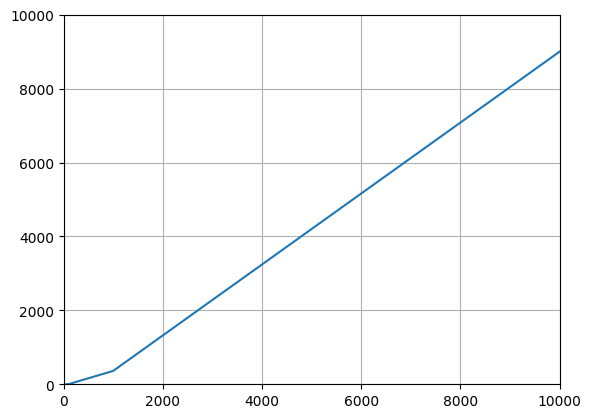

In [126]:
plt.plot(ls, collisions)
plt.grid()
plt.xlim([0, 10000])
plt.ylim([0, 10000])

(0.0, 1000.0)

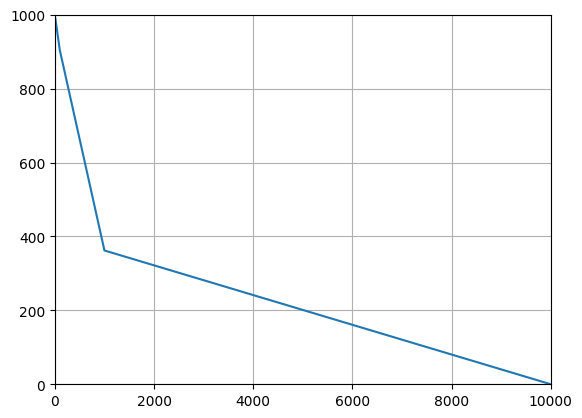

In [128]:
plt.plot(ls, free)
plt.grid()
plt.xlim([0, 10000])
plt.ylim([0, 1000])

In [ ]:
class HashTableOpenAddress:
    def __init__(self):
        self.coeff = 1000
        self.table = [None]* self.coeff
        self.collision_cnt = 0
        self.lost_cnt = 0
        self.max_steps = 0

    def _hash(self, key):
        return hash(key)

    def _index(self, key):
        h = self._hash(key)
        index = h % self.coeff
        return index

    def _search_free_index(self, index):
        for step in range(1, len(self.table)):
            new_index_down = max(index - step, 0)
            new_index_up = min(index + step, len(self.table)-1)
            if self.table[new_index_up] is None:
                self.max_steps = max(step, self.max_steps)
                return new_index_up
            if self.table[new_index_down] is None:
                self.max_steps = max(step, self.max_steps)
                return new_index_down
            if new_index_down == 0 and new_index_up == len(self.table)-1:
                return None

    def _search_key_index(self, index, key):
        for step in range(1, len(self.table)):
            new_index_down = max(index - step, 0)
            new_index_up = min(index + step, len(self.table)-1)
            if self.table[new_index_up] is not None:
                if self.table[new_index_up][0] == key:
                    return new_index_up
            if self.table[new_index_down] is not None:
                if self.table[new_index_down][0] == key:
                    return new_index_down
            if new_index_down == 0 and new_index_up == len(self.table)-1:
                return None

    def add(self, key, value):
        index = self._index(key)
        if self.table[index] is None:
            self.table[index] = (key, value)
            return
        else:
            self.collision_cnt += 1
            new_index = self._search_free_index(index)
            if new_index is not None:
                self.table[new_index] = (key, value)
            else:
                self.increase_table()
                self.add(key, value)

    def increase_table(self):ß
        print('increasing table')
        self.coeff *= 10
        old_table = self.table
        self.max_steps = 0
        self.table = [None]*self.coeff
        for elem in old_table:
            self.add(elem[0], elem[1])


    def get(self, key, default_value=None):
        index = self._index(key)
        if self.table[index]:
            if self.table[index][0] == key:
                return self.table[index][1]
            else:
                new_index = self._search_key_index(index, key)
                if new_index is not None:
                    return self.table[new_index][1]
        return default_value

    def get_free_cells(self):
        cnt = 0
        for i in range(len(self.table)):
            if self.table[i] is None:
                cnt += 1
        return cnt

In [154]:
hash_table = HashTableOpenAddress()
for i in range(10000):
    hash_table.add(str(i), i)

increasing table


In [155]:
hash_table.max_steps

9931

In [135]:
cnts = []
free = []
collisions = []
losts = []
ls = [10, 100, 1000]
for l in ls:
    hash_table = HashTableOpenAddress()
    for i in range(l):
        hash_table.add(str(i), i)
    collisions.append(hash_table.collision_cnt)
    free.append(hash_table.get_free_cells())
    losts.append(hash_table.lost_cnt)
    cnt = 0
    for i in range(l):
        elem = hash_table.get(str(i))
        if elem == i:
            cnt += 1
    cnts.append(cnt)
    

In [136]:
losts

[0, 0, 0]

In [138]:
free

[990, 900, 0]

In [139]:
cnts

[10, 100, 1000]

In [140]:
collisions

[0, 4, 518]